# Phân tích dữ liệu thời tiết Việt Nam


1. **Hiểu bộ dữ liệu là gì**
2. **Kiểm tra chất lượng dữ liệu**
3. **Làm sạch và chuẩn bị dữ liệu**
4. **Phân tích mô tả cơ bản**
5. **Phân tích thời tiết cực đoan**
6. **Phân tích nâng cao**


## Mục tiêu của bài phân tích
Bài này cố gắng trả lời các câu hỏi sau:

- Thời tiết ở Việt Nam nhìn chung có đặc điểm gì?
- Các vùng miền có khác nhau nhiều không?
- Sự khác nhau thể hiện theo **vùng**, **thời gian**, và **địa hình** như thế nào?
- Những dạng thời tiết cực đoan nào nổi bật?
- Nếu đi sâu hơn, ta có thể kiểm tra mức độ tin cậy của các kết luận bằng thống kê và mô hình như thế nào?

# 1. Hiểu bộ dữ liệu trước khi phân tích

#### Bộ dữ liệu này chứa gì?
- **Mỗi dòng** là dữ liệu thời tiết của **một địa điểm trong một ngày**
- **Mỗi cột** là một thuộc tính, ví dụ: nhiệt độ, lượng mưa, độ ẩm, chỉ số UV, gió, vùng miền, địa hình...

#### Việc cần làm
Trước khi phân tích, ta luôn nên:
1. Đọc dữ liệu vào Python
2. Xem vài dòng đầu tiên
3. Kiểm tra dữ liệu thiếu, dữ liệu trùng, dữ liệu bất thường
4. Chuẩn hóa một số cột để phân tích dễ hơn

In [9]:
# Import necessary libraries
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier


In [10]:
# Load the dataset
def load_data(file_path):
    return pd.read_csv(file_path)

data_path = Path('df_weather.csv')
df_weather = load_data(data_path)
df_weather.head()

,location.name,location.region,location.terrain,location.country,location.lat,location.lon,date,date_epoch,day.maxtemp_c,day.maxtemp_f,...,day.condition.text,day.condition.icon,day.condition.code,day.uv,astro.sunrise,astro.sunset,astro.moonrise,astro.moonset,astro.moon_phase,astro.moon_illumination
0,An Giang,Đồng Bằng Sông Cửu Long,đồng bằng,Vietnam,10.7000,105.1167,2024-04-21,1713657600,38.6,101.5,...,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,9.0,05:46 AM,06:11 PM,04:13 PM,03:55 AM,Waxing Gibbous,90
1,Bà Rịa-Vũng Tàu,Đông Nam Bộ,ven biển,Vietnam,10.3500,107.0667,2024-04-21,1713657600,30.2,86.3,...,Moderate rain at times,//cdn.weatherapi.com/weather/64x64/day/299.png,1186,7.0,05:38 AM,06:03 PM,04:05 PM,03:47 AM,Waxing Gibbous,90
2,Bắc Giang,Trung du và miền núi Bắc Bộ,miền núi,Vietnam,21.2667,106.2000,2024-04-21,1713657600,31.9,89.4,...,Heavy rain at times,//cdn.weatherapi.com/weather/64x64/day/305.png,1192,7.0,05:32 AM,06:16 PM,04:09 PM,03:53 AM,Waxing Gibbous,90
3,Bắc Kạn,Trung du và miền núi Bắc Bộ,miền núi,Vietnam,22.1333,105.8333,2024-04-21,1713657600,28.0,82.5,...,Moderate or heavy rain shower,//cdn.weatherapi.com/weather/64x64/day/356.png,1243,6.0,05:32 AM,06:19 PM,04:10 PM,03:54 AM,Waxing Gibbous,90
4,Bạc Liêu,Đồng Bằng Sông Cửu Long,ven biển,Vietnam,9.2850,105.7244,2024-04-21,1713657600,36.1,97.1,...,Partly cloudy,//cdn.weatherapi.com/weather/64x64/day/116.png,1003,9.0,05:45 AM,06:07 PM,04:11 PM,03:52 AM,Waxing Gibbous,90


## Các nhóm cột quan trọng

### 1) Nhóm thông tin địa điểm
- `location.name`: tên tỉnh/thành phố
- `location.region`: vùng miền
- `location.terrain`: loại địa hình
- `location.lat`, `location.lon`: vĩ độ và kinh độ

### 2) Nhóm thời gian
- `date`: ngày quan sát
- `month`: tháng (được tạo thêm từ cột `date`)

### 3) Nhóm chỉ số thời tiết chính
- `day.avgtemp_c`: nhiệt độ trung bình ngày
- `day.totalprecip_mm`: tổng lượng mưa trong ngày
- `day.avghumidity`: độ ẩm trung bình
- `day.maxwind_kph`: tốc độ gió lớn nhất
- `day.uv`: chỉ số UV

### 4) Nhóm phục vụ dự báo
- `day.daily_chance_of_rain`: xác suất mưa dự báo
- `day.daily_will_it_rain`: thực tế có mưa hay không

> Ta có thể coi 5 chỉ số quan trọng nhất của bài này là: **nhiệt độ, mưa, độ ẩm, gió, UV**.

## Ý nghĩa chi tiết các cột trong DataFrame `df_weather`

| Tên Cột                  | Kiểu dữ liệu | Mô tả                                                               |
| :----------------------- | :----------- | :------------------------------------------------------------------ |
| `location.name`          | `object`     | Tên địa điểm (tỉnh/thành phố).                                     |
| `location.region`        | `object`     | Vùng miền của địa điểm.                                            |
| `location.terrain`       | `object`     | Loại địa hình của địa điểm (ví dụ: đồng bằng, miền núi, ven biển).  |
| `location.country`       | `object`     | Quốc gia của địa điểm (trong trường hợp này là Việt Nam).           |
| `location.lat`           | `float64`    | Vĩ độ của địa điểm.                                                |
| `location.lon`           | `float64`    | Kinh độ của địa điểm.                                              |
| `date`                   | `datetime64` | Ngày dự báo thời tiết.                                             |
| `date_epoch`             | `int64`      | Thời gian dưới dạng Epoch (số giây kể từ 01/01/1970 UTC).           |
| `day.maxtemp_c`          | `float64`    | Nhiệt độ tối đa trong ngày (°C).                                   |
| `day.maxtemp_f`          | `float64`    | Nhiệt độ tối đa trong ngày (°F).                                   |
| `day.mintemp_c`          | `float64`    | Nhiệt độ tối thiểu trong ngày (°C).                                |
| `day.mintemp_f`          | `float64`    | Nhiệt độ tối thiểu trong ngày (°F).                                |
| `day.avgtemp_c`          | `float64`    | Nhiệt độ trung bình trong ngày (°C).                               |
| `day.avgtemp_f`          | `float64`    | Nhiệt độ trung bình trong ngày (°F).                               |
| `day.maxwind_mph`        | `float64`    | Tốc độ gió tối đa trong ngày (dặm/giờ).                            |
| `day.maxwind_kph`        | `float64`    | Tốc độ gió tối đa trong ngày (km/giờ).                             |
| `day.totalprecip_mm`     | `float64`    | Tổng lượng mưa trong ngày (mm).                                    |
| `day.totalprecip_in`     | `float64`    | Tổng lượng mưa trong ngày (inch).                                  |
| `day.totalsnow_cm`       | `float64`    | Tổng lượng tuyết rơi trong ngày (cm).                               |
| `day.avgvis_km`          | `float64`    | Tầm nhìn trung bình trong ngày (km).                               |
| `day.avgvis_miles`       | `float64`    | Tầm nhìn trung bình trong ngày (dặm).                              |
| `day.avghumidity`        | `int64`      | Độ ẩm trung bình trong ngày (%).                                   |
| `day.daily_will_it_rain` | `int64`      | Có mưa trong ngày hay không (1 = Có, 0 = Không).                    |
| `day.daily_chance_of_rain` | `int64`    | Khả năng mưa trong ngày (%).                                       |
| `day.condition.text`     | `object`     | Mô tả điều kiện thời tiết (ví dụ: "Sunny", "Partly cloudy").       |
| `day.condition.icon`     | `object`     | Liên kết đến biểu tượng điều kiện thời tiết.                       |
| `day.condition.code`     | `int64`      | Mã số điều kiện thời tiết.                                         |
| `day.uv`                 | `float64`    | Chỉ số tia UV.                                                     |
| `astro.sunrise`          | `object`     | Thời gian mặt trời mọc.                                            |
| `astro.sunset`           | `object`     | Thời gian mặt trời lặn.                                            |
| `astro.moonrise`         | `object`     | Thời gian trăng mọc.                                               |
| `astro.moonset`          | `object`     | Thời gian trăng lặn.                                               |
| `astro.moon_phase`       | `object`     | Giai đoạn mặt trăng.                                              |
| `astro.moon_illumination` | `int64`     | Độ sáng của mặt trăng (%).                                         |

Các cột này cung cấp một cái nhìn toàn diện về điều kiện thời tiết tại các địa điểm khác nhau ở Việt Nam, bao gồm thông tin về nhiệt độ, độ ẩm, gió, lượng mưa, tầm nhìn và các yếu tố thiên văn khác.

# 2. Kiểm tra chất lượng dữ liệu

Đây là bước cực kỳ quan trọng, vì nếu dữ liệu có lỗi mà không kiểm tra trước, những kết luận của chúng ta sẽ không còn độ chính xác nữa.

#### Ta nên kiểm tra những gì?
- **Missing values**: ô trống / dữ liệu thiếu
- **Duplicate rows**: dòng bị lặp
- **Outlier**: giá trị quá khác biệt so với phần lớn dữ liệu

#### Vì sao cần kiểm tra?
- Dữ liệu thiếu có thể làm sai phép tính trung bình
- Dữ liệu trùng có thể làm một địa điểm bị đếm hai lần
- Trong dữ liệu thời tiết, tất nhiên sẽ có những trường hợp bất thường như lượng mưa lớn đột ngột, nhưng chúng cũng có thể là lỗi nhập liệu.

In [11]:
# Data quality audit

audit_df = df_weather.copy()
audit_df['date'] = pd.to_datetime(audit_df['date'], errors='coerce')

missing_by_col = audit_df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(audit_df.duplicated().sum())

# Outlier detection using IQR method
numeric_cols = ['day.avgtemp_c', 'day.totalprecip_mm', 'day.maxwind_kph', 'day.avghumidity', 'day.uv']
outlier_summary = []
for col in numeric_cols:
    q1, q3 = audit_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_rate = ((audit_df[col] < lower) | (audit_df[col] > upper)).mean() * 100
    outlier_summary.append((col, q1, q3, iqr, outlier_rate))
outlier_df = pd.DataFrame(outlier_summary, columns=['feature', 'q1', 'q3', 'iqr', 'outlier_rate_pct'])

# Label consistency checks
region_values = sorted(audit_df['location.region'].dropna().unique())
terrain_values = sorted(audit_df['location.terrain'].dropna().unique())

print('=== Data Quality Audit ===')
print(f'Tổng số dòng: {len(audit_df):,}')
print(f'Số dòng trùng lặp hoàn toàn: {duplicate_rows}')
print('\nTop 10 cột có missing nhiều nhất:')
display(missing_by_col.head(10).to_frame('missing_count'))

print('\nTỷ lệ outlier theo IQR (%):')
display(outlier_df.sort_values('outlier_rate_pct', ascending=False))

print('\nNhãn vùng (location.region):')
print(region_values)
print('\nNhãn địa hình (location.terrain):')
print(terrain_values)

=== Data Quality Audit ===
Tổng số dòng: 26,018
Số dòng trùng lặp hoàn toàn: 252

Top 10 cột có missing nhiều nhất:


,missing_count
location.name,0
location.region,0
location.terrain,0
location.country,0
location.lat,0
location.lon,0
date,0
date_epoch,0
day.maxtemp_c,0
day.maxtemp_f,0



Tỷ lệ outlier theo IQR (%):


,feature,q1,q3,iqr,outlier_rate_pct
1,day.totalprecip_mm,0.01,8.3,8.29,8.601737
4,day.uv,6.00,7.0,1.00,6.837574
0,day.avgtemp_c,22.80,28.1,5.30,2.555923
3,day.avghumidity,70.00,85.0,15.00,1.518180
2,day.maxwind_kph,10.80,19.1,8.30,1.026213



Nhãn vùng (location.region):
['Bắc Trung Bộ và Duyên hải miền Trung', 'Tr [*]ung du và miền núi Bắc Bộ', 'Trung du và miền núi Bắc Bộ', 'Tây Nguyên', 'Đông Nam Bộ', 'Đồng Bằng Sông Cửu Long', 'Đồng Bằng Sông Hồng']

Nhãn địa hình (location.terrain):
['miền núi', 'ven biển', 'đồng bằng']


#### **Nhận xét:**

- Dữ liệu có quy mô lớn (khoảng 26k dòng), không có thiếu dữ liệu ở các cột chính dùng để mô hình hóa và phân tích.
- Có một số dòng trùng lặp hoàn toàn (khoảng 252 dòng), nếu muốn phân tích nhạy cảm hơn, chúng ta cần loại bỏ nó.
- **Outlier ở lượng mưa và UV**: điều này hợp lý, vì thời tiết vốn có những ngày mưa cực lớn hoặc nắng rất gắt.

#### Thuật ngữ:

- ***IQR (Interquartile Range)**: khoảng tứ phân vị, thường dùng để phát hiện outlier.*
- ***Outlier**: điểm dữ liệu lệch xa phần còn lại.*

# 3. Làm sạch và chuẩn bị dữ liệu

Sau khi kiểm tra xong, ta cần chuẩn bị dữ liệu để phân tích dễ hơn.

- Sửa tên vùng bị lỗi ký tự, giúp tên vùng viết thống nhất
- Chuyển cột `date` sang kiểu ngày tháng để dễ lọc theo thời gian
- Tạo thêm cột `month` để phân tích theo mùa
- Tính bảng tổng hợp theo **vùng miền** và **tháng**, giúp vẽ biểu đồ xu hướng theo năm


In [12]:
# Fix data issues
df_weather['location.region'] = df_weather['location.region'].replace('Tr [*]ung du và miền núi Bắc Bộ', 'Trung du và miền núi Bắc Bộ')

print("Unique regions after standardization:")
print(df_weather['location.region'].unique())

Unique regions after standardization:
<ArrowStringArray>
[             'Đồng Bằng Sông Cửu Long',
                          'Đông Nam Bộ',
          'Trung du và miền núi Bắc Bộ',
                  'Đồng Bằng Sông Hồng',
 'Bắc Trung Bộ và Duyên hải miền Trung',
                           'Tây Nguyên']
Length: 6, dtype: str


In [13]:

# 1. Convert the 'date' column in df_weather to datetime objects
df_weather['date'] = pd.to_datetime(df_weather['date'])

# 2. Extract the month from the 'date' column and store it in a new column called 'month'
df_weather['month'] = df_weather['date'].dt.month

# 3. Create a new DataFrame called monthly_weather_summary by grouping df_weather
# by 'location.region' and 'month'. Calculate the mean of 'day.avgtemp_c' and
# 'day.totalprecip_mm' for each group. Reset the index of the resulting DataFrame.
monthly_weather_summary = df_weather.groupby(['location.region', 'month'])[['day.avgtemp_c', 'day.totalprecip_mm']].mean().reset_index()

# 4. Define a list named desired_region_order
desired_region_order = [
    'Trung du và miền núi Bắc Bộ',
    'Đồng Bằng Sông Hồng',
    'Bắc Trung Bộ và Duyên hải miền Trung',
    'Tây Nguyên',
    'Đông Nam Bộ',
    'Đồng Bằng Sông Cửu Long'
]

print("Data preparation for monthly heatmaps complete.")
print("First 5 rows of monthly_weather_summary:")
print(monthly_weather_summary.head())
print("\nDesired region order:")
print(desired_region_order)

Data preparation for monthly heatmaps complete.
First 5 rows of monthly_weather_summary:
                        location.region  month  day.avgtemp_c  \
0  Bắc Trung Bộ và Duyên hải miền Trung      1      20.014286   
1  Bắc Trung Bộ và Duyên hải miền Trung      2      21.340816   
2  Bắc Trung Bộ và Duyên hải miền Trung      3      22.905069   
3  Bắc Trung Bộ và Duyên hải miền Trung      4      26.523260   
4  Bắc Trung Bộ và Duyên hải miền Trung      5      27.861678   

   day.totalprecip_mm  
0            2.359493  
1            4.335179  
2            3.214793  
3            1.124634  
4            5.425646  

Desired region order:
['Trung du và miền núi Bắc Bộ', 'Đồng Bằng Sông Hồng', 'Bắc Trung Bộ và Duyên hải miền Trung', 'Tây Nguyên', 'Đông Nam Bộ', 'Đồng Bằng Sông Cửu Long']


# 4. Phân tích mô tả cơ bản

Mục tiêu là trả lời: **thời tiết Việt Nam nhìn chung như thế nào?**

Chúng ta sẽ dùng:
- Trung bình
- Tỷ lệ
- Biểu đồ
- So sánh theo nhóm

Cách phân tích này đơn giản nhưng giúp chúng ta thấy được bức tranh lớn tổng thể về thời tiết.

## 4.1. Bức tranh chung theo vùng miền

Ở phần này, ta lấy trung bình của 3 chỉ số chính:
- Nhiệt độ
- Lượng mưa
- Độ ẩm

In [14]:
# 1. Calculate regional averages
regional_averages = df_weather.groupby('location.region')[['day.avgtemp_c', 'day.totalprecip_mm', 'day.avghumidity']].mean().reset_index()
regional_averages.rename(columns={'day.avgtemp_c': 'avg_temp_c', 'day.totalprecip_mm': 'avg_precip_mm', 'day.avghumidity': 'avg_humidity'}, inplace=True)

# 2. Calculate overall averages
overall_averages = df_weather[['day.avgtemp_c', 'day.totalprecip_mm', 'day.avghumidity']].mean().to_frame().T
overall_averages['location.region'] = 'Toàn quốc'
overall_averages.rename(columns={'day.avgtemp_c': 'avg_temp_c', 'day.totalprecip_mm': 'avg_precip_mm', 'day.avghumidity': 'avg_humidity'}, inplace=True)

# Ensure column order is consistent before concatenation
overall_averages = overall_averages[regional_averages.columns]

# 3. Concatenate the DataFrames
all_averages = pd.concat([regional_averages, overall_averages], ignore_index=True)

print("DataFrame 'all_averages' created successfully:")
print(all_averages)

DataFrame 'all_averages' created successfully:
                        location.region  avg_temp_c  avg_precip_mm  \
0  Bắc Trung Bộ và Duyên hải miền Trung   25.599464       6.826441   
1           Trung du và miền núi Bắc Bộ   22.298945       6.526685   
2                            Tây Nguyên   22.784939       5.463191   
3                           Đông Nam Bộ   27.790557       6.510593   
4               Đồng Bằng Sông Cửu Long   27.579084       6.951140   
5                   Đồng Bằng Sông Hồng   24.622369       6.592886   
6                             Toàn quốc   25.089223       6.606506   

   avg_humidity  
0     80.192667  
1     77.211000  
2     80.247458  
3     73.274415  
4     74.963867  
5     74.505284  
6     76.803636  


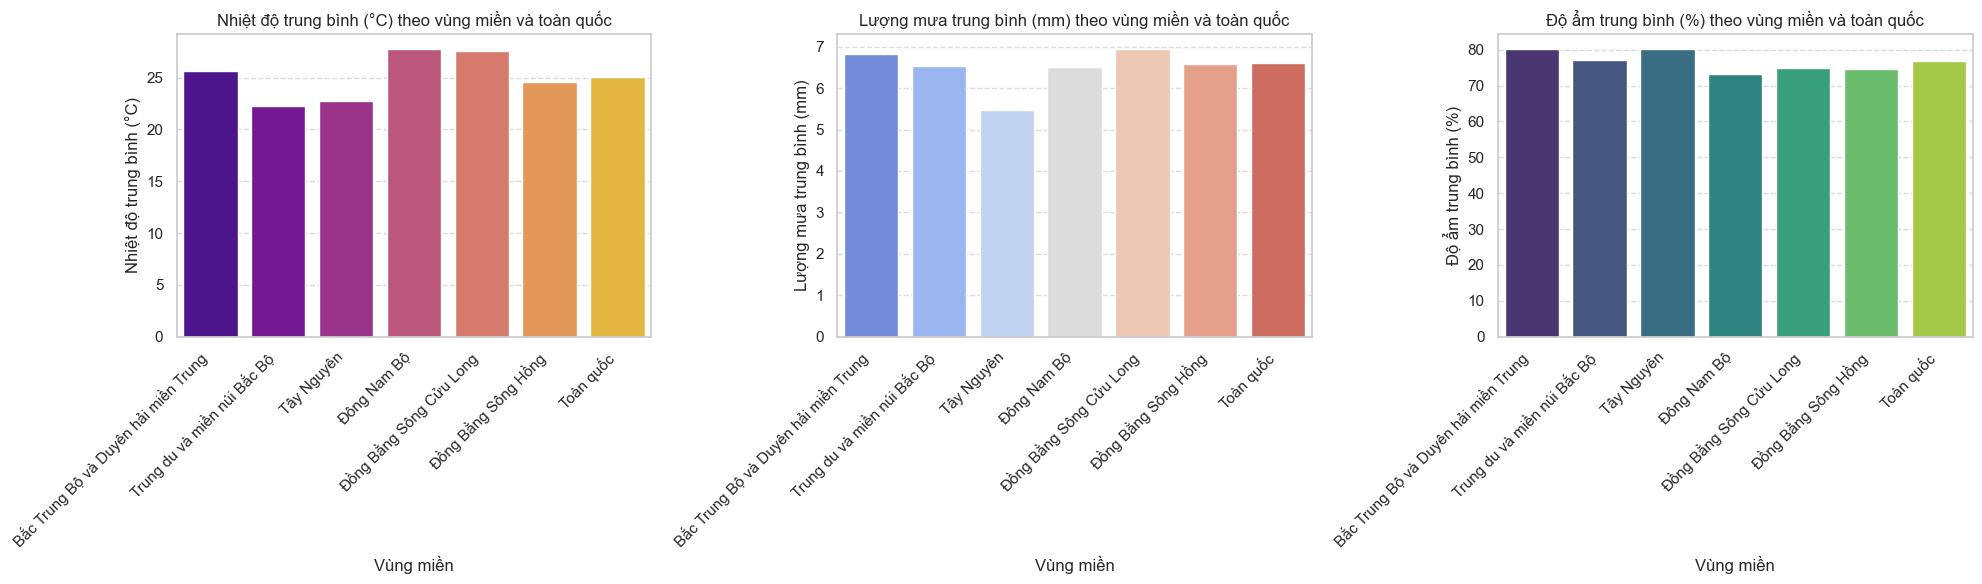

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define common x-labels for all subplots
x_labels = all_averages['location.region'].unique()

# Subplot 1: Average Temperature
sns.barplot(x='location.region', y='avg_temp_c', data=all_averages, palette='plasma', ax=axes[0], hue='location.region', legend=False)
axes[0].set_title('Nhiệt độ trung bình (°C) theo vùng miền và toàn quốc')
axes[0].set_xlabel('Vùng miền')
axes[0].set_ylabel('Nhiệt độ trung bình (°C)')
axes[0].set_xticks(range(len(x_labels)))
axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Average Precipitation
sns.barplot(x='location.region', y='avg_precip_mm', data=all_averages, palette='coolwarm', ax=axes[1], hue='location.region', legend=False)
axes[1].set_title('Lượng mưa trung bình (mm) theo vùng miền và toàn quốc')
axes[1].set_xlabel('Vùng miền')
axes[1].set_ylabel('Lượng mưa trung bình (mm)')
axes[1].set_xticks(range(len(x_labels)))
axes[1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 3: Average Humidity
sns.barplot(x='location.region', y='avg_humidity', data=all_averages, palette='viridis', ax=axes[2], hue='location.region', legend=False)
axes[2].set_title('Độ ẩm trung bình (%) theo vùng miền và toàn quốc')
axes[2].set_xlabel('Vùng miền')
axes[2].set_ylabel('Độ ẩm trung bình (%)')
axes[2].set_xticks(range(len(x_labels)))
axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### **Nhận xét**: 
- Bao trùm các miền địa lý Việt Nam là kiểu thời tiết nóng lắm, mưa nhiều, tạo cảm giác oi bức, phù hợp với tính chất của khí hậu nhiệt đới: các miền đều có nhiệt độ trung bình trên 20°C, lượng mưa trung bình ngày trên 5mm (tức hơn 1500mm/năm), độ ẩm > 70%. 
- Nhìn vào cả 3 biểu đồ trên, có thể thấy chênh lệch giữa trung bình nhiệt độ, độ ẩm và lượng mưa giữa các vùng miền không lớn. Điều này càng được khẳng định khi ta so sánh tương quan giữa tọa độ địa lý và các chỉ số thời tiết.

## 4.2. Sự khác nhau theo không gian và thời gian

Ở đây có hai ý quan trọng:

### a) Theo vị trí địa lý
Ta xem vĩ độ, kinh độ có liên hệ với nhiệt độ và lượng mưa hay không.

- Nếu tương quan yếu → thời tiết giữa các nơi không khác quá mạnh chỉ vì tọa độ
- Nếu tương quan rõ → vị trí địa lý có tác động đáng kể

### b) Theo thời gian trong năm
Ta gom dữ liệu theo **tháng** để xem:
- tháng nào nóng nhất
- tháng nào mưa nhiều nhất
- mỗi vùng có mùa giống hay khác nhau

### Thuật ngữ:
- ***Correlation / tương quan**: mức độ hai biến thay đổi cùng nhau.*
- ***Pivot table**: bảng tổng hợp giúp đổi dữ liệu về dạng dễ nhìn và dễ vẽ biểu đồ.*
- ***Seasonality / tính mùa vụ**: mẫu lặp lại theo mùa hoặc theo tháng.*

### 4.2.1. Phân hóa theo vị trí địa lý

Số lượng giá trị thiếu trước khi xử lý:
location.lat          0
location.lon          0
day.avgtemp_c         0
day.totalprecip_mm    0
dtype: int64

Số lượng giá trị thiếu sau khi xử lý:
location.lat          0
location.lon          0
day.avgtemp_c         0
day.totalprecip_mm    0
dtype: int64

DataFrame dành cho phân tích tương quan (5 hàng đầu):
   location.lat  location.lon  day.avgtemp_c  day.totalprecip_mm
0       10.7000      105.1167           31.7                 0.0
1       10.3500      107.0667           29.2                 1.5
2       21.2667      106.2000           28.0                 3.8
3       22.1333      105.8333           25.1                16.1
4        9.2850      105.7244           30.7                 0.0
Ma trận tương quan:
                    location.lat  location.lon  day.avgtemp_c  \
location.lat            1.000000     -0.379177      -0.403656   
location.lon           -0.379177      1.000000       0.136872   
day.avgtemp_c          -0.403656      0.136

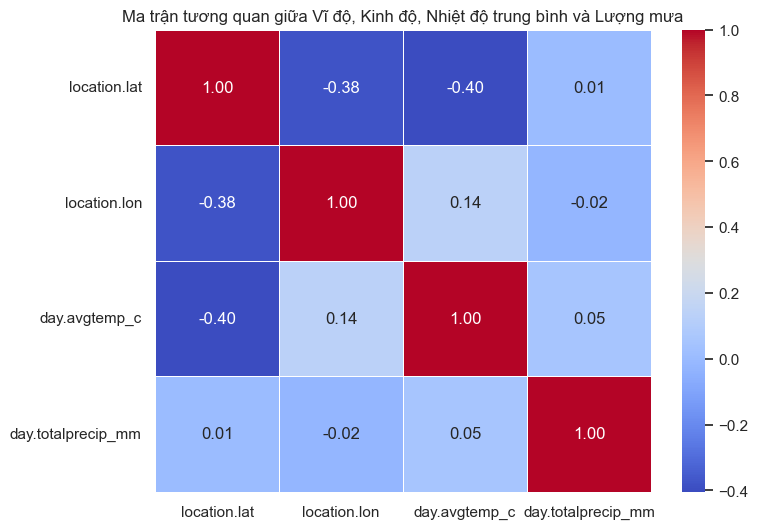

In [16]:
selected_columns = ['location.lat', 'location.lon', 'day.avgtemp_c', 'day.totalprecip_mm']
df_correlation = df_weather[selected_columns].copy()

print("Số lượng giá trị thiếu trước khi xử lý:")
print(df_correlation.isnull().sum())

df_correlation.dropna(inplace=True)

print("\nSố lượng giá trị thiếu sau khi xử lý:")
print(df_correlation.isnull().sum())

print("\nDataFrame dành cho phân tích tương quan (5 hàng đầu):")
print(df_correlation.head())

correlation_matrix = df_correlation.corr()

print("Ma trận tương quan:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan giữa Vĩ độ, Kinh độ, Nhiệt độ trung bình và Lượng mưa')
plt.show()


#### **Nhận xét**: 
- Có thể thấy tọa độ địa lý **tương quan yếu** với chỉ số thời tiết, tức tính chất thời tiết khá đồng nhất, không khác biệt nhiều giữa các miền. Trong đó, có mối tương quan âm giữa vĩ độ và nhiệt độ trung bình (-0.4), cho thấy khi vĩ độ tăng (càng xa xích đạo), nhiệt độ trung bình có xu hướng giảm.
- Song khi xét theo thời gian, giữa các miền địa lý lại có những sự khác biệt rõ rệt về biểu hiện thời tiết. Biểu đồ dưới đây cho thấy biến động nhiệt độ và lượng mưa trong năm theo từng miền:

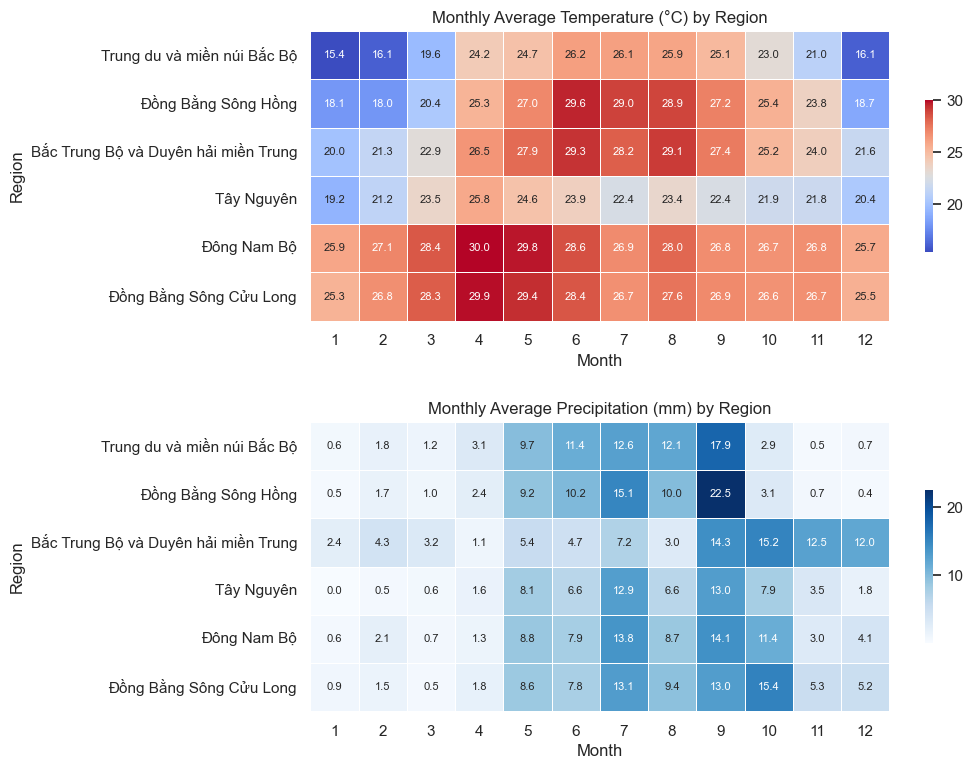

In [17]:
# 1. Create a pivot table named temp_pivot
temp_pivot = monthly_weather_summary.pivot_table(
    index='location.region',
    columns='month',
    values='day.avgtemp_c',
    observed=False
)

# 2. Reorder the rows of temp_pivot
temp_pivot_reordered = temp_pivot.reindex(desired_region_order)

# 3. Create a pivot table named precip_pivot
precip_pivot = monthly_weather_summary.pivot_table(
    index='location.region',
    columns='month',
    values='day.totalprecip_mm',
    observed=False
)

# 4. Reorder the rows of precip_pivot
precip_pivot_reordered = precip_pivot.reindex(desired_region_order)

# 5. Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8)) # 2 rows, 1 column
plt.subplots_adjust(hspace=0.2)

# 6. Top heatmap: Monthly Average Temperature
sns.heatmap(
    temp_pivot_reordered,
    cmap='coolwarm',
    annot=True,
    fmt=".1f",
    linewidths=.5,
    square=True,
    annot_kws={'fontsize': 8},
    cbar_kws={"shrink": 0.5},
    ax=axes[0]
)
axes[0].set_title('Monthly Average Temperature (°C) by Region')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Region')

# 7. Bottom heatmap: Monthly Average Precipitation
sns.heatmap(
    precip_pivot_reordered,
    cmap='Blues',
    annot=True,
    fmt=".1f",
    linewidths=.5,
    square=True,
    annot_kws={'fontsize': 8},
    cbar_kws={"shrink": 0.5},
    ax=axes[1]
)
axes[1].set_title('Monthly Average Precipitation (mm) by Region')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Region')

# 8. Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# 9. Display the plot
plt.show()


#### Phân tích biểu đồ Nhiệt độ trung bình hàng tháng theo vùng miền:

*   **Xu hướng chung**: Hầu hết các vùng miền đều có nhiệt độ cao, nhất vào các tháng giữa năm (tháng 4 - tháng 8) và thấp nhất vào các tháng đầu và cuối năm (tháng 12 - tháng 2), phản ánh rõ rệt chu kỳ mùa.
*   **Đồng Bằng Sông Cửu Long và Đông Nam Bộ**: Duy trì nhiệt độ cao ổn định quanh năm, ít biến động theo mùa so với các vùng khác, với nhiệt độ trung bình thường trên 25°C. Nhiệt độ đạt đỉnh vào khoảng tháng 4-5.
*   **Bắc Trung Bộ và Duyên hải miền Trung**: Có sự biến động nhiệt độ rõ rệt giữa các mùa. Nhiệt độ thấp nhất vào mùa đông và tăng dần đến mùa hè, với đỉnh điểm vào tháng 6-7.
*   **Trung du và miền núi Bắc Bộ, Đồng Bằng Sông Hồng**: Nhiệt độ có sự chênh lệch lớn nhất giữa mùa đông và mùa hè. Mùa đông (tháng 12 - tháng 2) khá lạnh, đặc biệt ở Trung du và miền núi Bắc Bộ, trong khi mùa hè (tháng 6 - tháng 8) nhiệt độ tăng cao. Trung du và miền núi Bắc Bộ thường có nhiệt độ thấp nhất cả nước vào mùa đông.
*   **Tây Nguyên**: Nhiệt độ ôn hòa hơn so với các vùng khác, ít biến động mạnh, nhưng vẫn có xu hướng tăng vào mùa khô và giảm nhẹ vào mùa mưa.

#### Phân tích biểu đồ Lượng mưa trung bình hàng tháng theo vùng miền:

*   **Xu hướng chung**: Hầu hết các vùng miền đều có mùa mưa rõ rệt, tập trung vào các tháng giữa và cuối năm (tháng 5 - tháng 10), và mùa khô vào các tháng đầu năm.
*   **Đồng Bằng Sông Cửu Long và Đông Nam Bộ**: Có mùa mưa kéo dài, với lượng mưa cao nhất vào khoảng tháng 9-10. Mùa khô kéo dài từ tháng 12 đến tháng 4.
*   **Bắc Trung Bộ và Duyên hải miền Trung**: Lượng mưa phân bố không đều. Vùng này thường chịu ảnh hưởng của bão và áp thấp nhiệt đới, gây mưa lớn vào các tháng cuối năm (tháng 9 - tháng 11), đôi khi có những đợt mưa trái mùa.
*   **Trung du và miền núi Bắc Bộ, Đồng Bằng Sông Hồng**: Mưa lớn tập trung vào mùa hè (tháng 6 - tháng 9), đặc biệt là vào tháng 7-8. Đây cũng là mùa bão và lũ lụt ở miền Bắc.
*   **Tây Nguyên**: Có mùa mưa rõ rệt từ tháng 5 đến tháng 10, với lượng mưa đạt đỉnh vào khoảng tháng 8-9. Mùa khô rất rõ ràng với lượng mưa thấp kỷ lục từ tháng 12 đến tháng 4.


#### Kết luận
*   Trong khi các miền địa lý phía Bắc có 2 nền nhiệt khác biệt rõ rệt trong năm: nóng vào hè - thu, lạnh vào xuân và đông thì phía Nam nóng đều quanh năm, nhiệt độ không có sự chênh lệch lớn.
*   Thời điểm nóng nhất trong năm ở phía Nam trùng vào cuối mùa khô, còn thời điểm nóng nhất trong năm ở phía Bắc trùng vào mùa mưa. Điều đó tạo nên 2 kiểu khí hậu khá điển hình: trong Nam là khí hậu cận xích đạo gồm mùa mưa và mùa khô, phía Bắc là khí hậu gió mùa gồm mùa đông lạnh khô và mùa hè nóng ẩm.
*   Mùa mưa không giống nhau giữa các vùng.
*   Cùng là Việt Nam nhưng nhịp thời tiết theo tháng có sự phân hóa khá rõ.

### 4.2.2. Phân hóa theo thời gian

Phần này không trực tiếp nói về mưa hay nhiệt độ, nhưng nó giúp ta hiểu rằng:
- Các chỉ số theo thời gian không đứng yên
- Nhiều hiện tượng khí hậu chịu ảnh hưởng của chu kỳ trong năm

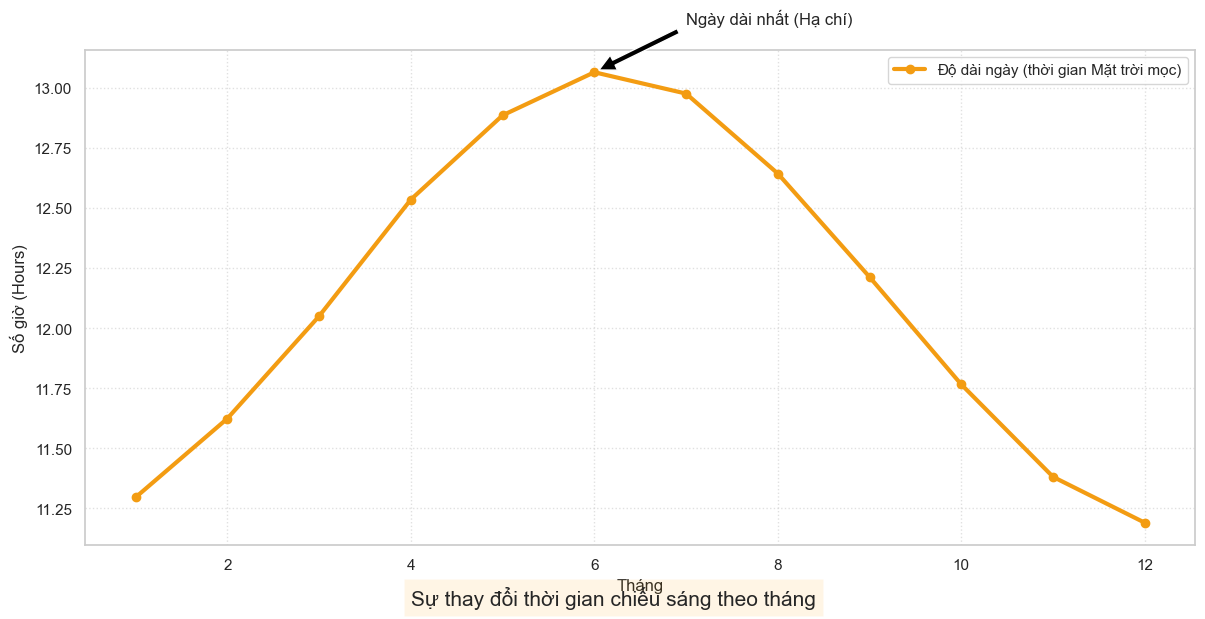

In [18]:
# 1. Chuẩn bị dữ liệu
df = df_weather.copy()
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# Hàm chuyển đổi thời gian AM/PM sang số giờ (decimal hours)
def time_to_hours(time_str):
    try:
        return pd.to_datetime(time_str, format='%I:%M %p').hour + \
               pd.to_datetime(time_str, format='%I:%M %p').minute / 60
    except:
        return None

# 2. Tính toán độ dài thời gian (đơn vị: Giờ)
# Độ dài ngày = Sunset - Sunrise
df['day_length'] = df['astro.sunset'].apply(time_to_hours) - df['astro.sunrise'].apply(time_to_hours)


# 3. Gom nhóm theo tháng
monthly_astro = df.groupby('month').agg({
    'day_length': 'mean',
}).sort_index()

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 6))

plt.plot(monthly_astro.index, monthly_astro['day_length'],
         marker='o', linewidth=3, color='#f39c12', label='Độ dài ngày (thời gian Mặt trời mọc)')

# 5. Tinh chỉnh biểu đồ

plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số giờ (Hours)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.figtext(0.5, 0.01, "Sự thay đổi thời gian chiếu sáng theo tháng",
            ha="center", fontsize=15, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})
plt.subplots_adjust(bottom=0.7)

# 6. Thêm ghi chú về hiện tượng "Ngày dài đêm ngắn"
plt.annotate('Ngày dài nhất (Hạ chí)', xy=(6, monthly_astro['day_length'].max()),
             xytext=(7, monthly_astro['day_length'].max()+0.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

#### **Nhận xét**: 
- Độ dài ngày tăng dần từ đầu năm và đạt đỉnh vào khoảng tháng 6 (Hạ chí) rồi giảm dần về những tháng cuối năm. Đây là biểu hiện rõ rệt của một quốc gia ở bán cầu Bắc như Việt Nam, đồng thời phản ánh một tính chất thời gian rất đặc trưng: "Đêm tháng Năm chưa nằm đã sáng, ngày tháng Mười chưa cười đã tối".



## 4.3. Sự khác nhau theo địa hình

Địa hình có ảnh hưởng nhiều đến:
- Nhiệt độ
- Mưa
- Gió
- Biên độ nhiệt giữa ngày và đêm

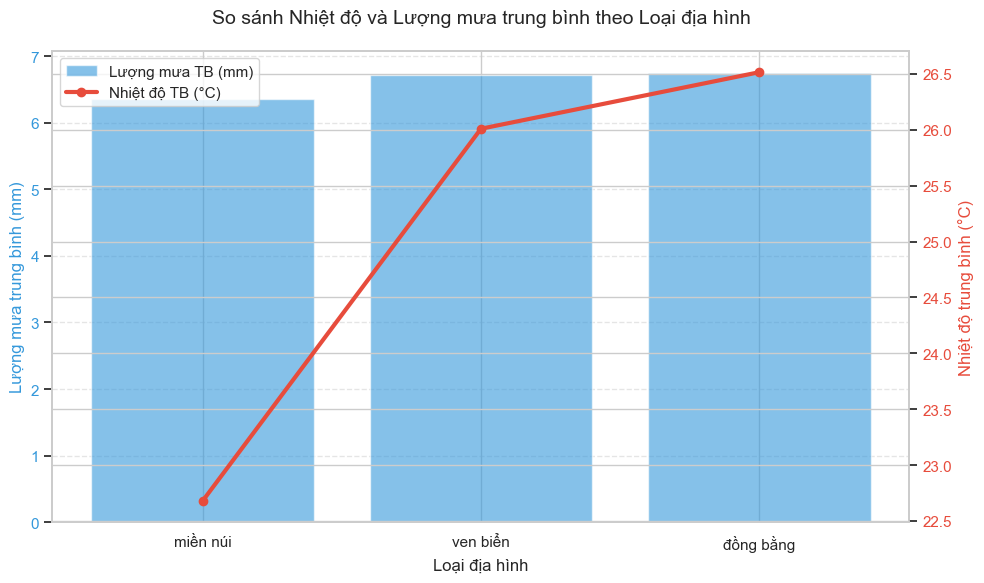

In [19]:
# 1. Chuẩn bị dữ liệu
df = df_weather.copy()

# 2. Tính toán giá trị trung bình theo loại địa hình (location.terrain)
terrain_stats = df.groupby('location.terrain').agg({
    'day.avgtemp_c': 'mean',
    'day.totalprecip_mm': 'mean'
}).sort_values('day.avgtemp_c')

# 3. Khởi tạo biểu đồ
fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục y thứ nhất: Lượng mưa trung bình (Cột)
color_rain = '#3498db'
ax1.bar(terrain_stats.index, terrain_stats['day.totalprecip_mm'], color=color_rain, alpha=0.6, label='Lượng mưa TB (mm)')
ax1.set_xlabel('Loại địa hình', fontsize=12)
ax1.set_ylabel('Lượng mưa trung bình (mm)', color=color_rain, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_rain)

# Trục y thứ hai: Nhiệt độ trung bình (Đường)
ax2 = ax1.twinx()
color_temp = '#e74c3c'
ax2.plot(terrain_stats.index, terrain_stats['day.avgtemp_c'], color=color_temp, marker='o', linewidth=3, label='Nhiệt độ TB (°C)')
ax2.set_ylabel('Nhiệt độ trung bình (°C)', color=color_temp, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_temp)

# 4. Tùy chỉnh tiêu đề và lưới
plt.title('So sánh Nhiệt độ và Lượng mưa trung bình theo Loại địa hình', fontsize=14, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm chú thích cho cả 2 trục
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

#### **Nhận xét**: 
- Khu vực miền núi có nhiệt độ trung bình và lượng mưa thấp hơn hẳn 2 khu vực còn lại, cho thấy thời tiết ở đây có xu hướng mát mẻ và dễ chịu hơn.
- Khu vực ven biển và đồng bằng không có sự khác biệt quá lớn về các chỉ số thời tiết, cho thấy sự đồng đều về tính chất khí hậu.

# 5. Phân tích thời tiết cực đoan

Sau khi đã hiểu bức tranh chung, ta chuyển sang phần khó hơn một chút:
**những ngày thời tiết khắc nghiệt**.

Phần này tập trung vào 4 câu hỏi:
1. Chỉ số UV ở Việt Nam thường ở mức nào?
2. Mưa vừa / mưa to xuất hiện nhiều không?
3. Mưa lớn có thường đi kèm gió lớn không?
4. Biên độ nhiệt ngày - đêm khác nhau ra sao giữa các địa hình?

#### Thuật ngữ:
- **UV index**: chỉ số bức xạ tia cực tím từ mặt trời.
- **Temperature range / biên độ nhiệt**: chênh lệch giữa nhiệt độ cao nhất và thấp nhất trong ngày.
- **Scatter plot**: biểu đồ chấm, dùng để nhìn mối liên hệ giữa hai biến.
- **Boxplot**: biểu đồ hộp, dùng để nhìn phân bố dữ liệu và độ trải rộng.

## 5.1. Các biểu hiện cực đoan nổi bật

Ở phần này, chúng mình lần lượt xét đến:
- Mức độ UV
- Cường độ mưa
- Mối liên hệ giữa mưa và gió
- Biên độ nhiệt giữa ngày và đêm

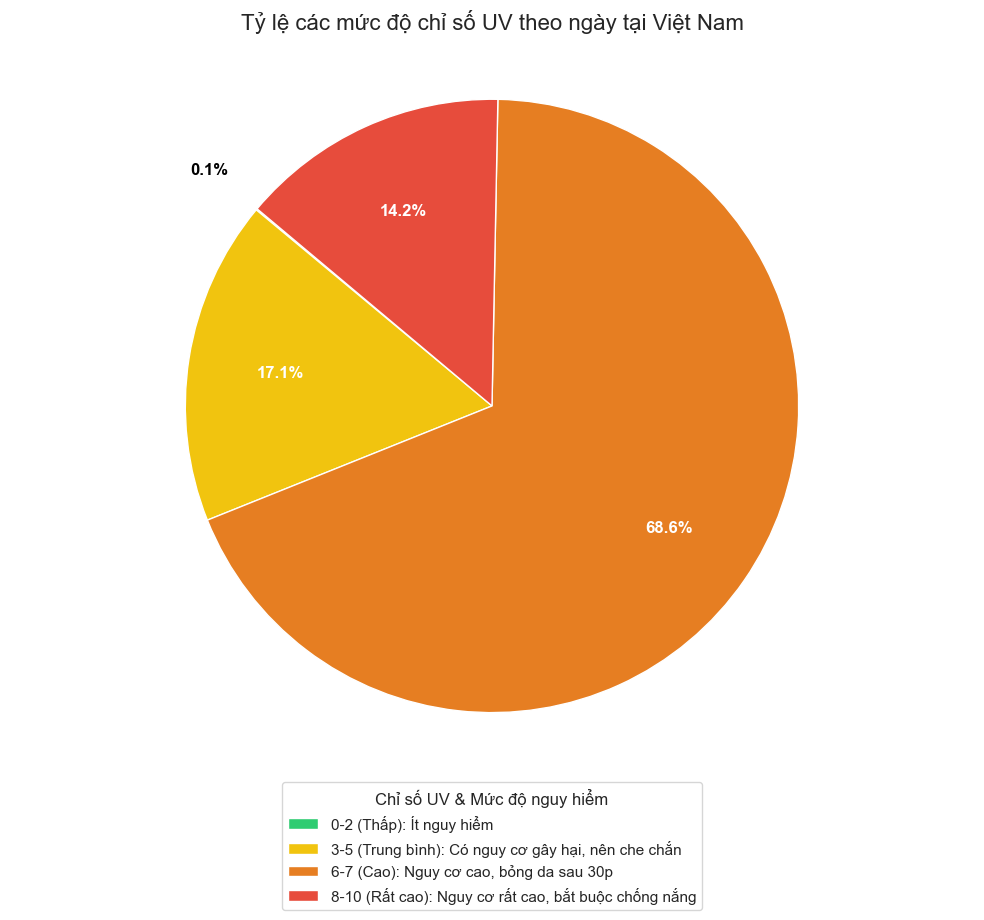

In [20]:
# 1. Chuẩn bị dữ liệu từ df_weather
df = df_weather.copy()

def classify_uv(uv):
    if uv <= 2: return '0-2 (Thấp)'
    elif 3 <= uv <= 5: return '3-5 (Trung bình)'
    elif 6 <= uv <= 7: return '6-7 (Cao)'
    elif 8 <= uv <= 10: return '8-10 (Rất cao)'
    else: return '11+ (Cực kỳ cao)'

df['uv_rank'] = df['day.uv'].apply(classify_uv)
uv_counts = df['uv_rank'].value_counts()

# Sắp xếp theo thứ tự cấp độ
order = ['0-2 (Thấp)', '3-5 (Trung bình)', '6-7 (Cao)', '8-10 (Rất cao)', '11+ (Cực kỳ cao)']
uv_counts = uv_counts.reindex([r for r in order if r in uv_counts.index]).fillna(0)

# Chú thích mức độ nguy hiểm
descriptions = {
    '0-2 (Thấp)': 'Ít nguy hiểm',
    '3-5 (Trung bình)': 'Có nguy cơ gây hại, nên che chắn',
    '6-7 (Cao)': 'Nguy cơ cao, bỏng da sau 30p',
    '8-10 (Rất cao)': 'Nguy cơ rất cao, bắt buộc chống nắng',
    '11+ (Cực kỳ cao)': 'Cực kỳ nguy hiểm, nên ở trong nhà'
}

# 2. Cấu hình màu sắc
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']

# 3. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 10)) # Tăng chiều cao để đủ chỗ cho chú thích bên dưới

# Vẽ pie chart (hình tròn nguyên vẹn)
wedges, texts, autotexts = ax.pie(
    uv_counts,
    labels=None,
    autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
    startangle=140,
    colors=colors[:len(uv_counts)],
    pctdistance=0.7,
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'white'}
)

# Xử lý nhãn < 1% đẩy ra ngoài
total = uv_counts.sum()
for i, p in enumerate((uv_counts / total) * 100):
    if 0 < p < 1:
        angle = (wedges[i].theta2 + wedges[i].theta1) / 2.
        x = 1.2 * np.cos(np.deg2rad(angle))
        y = 1.2 * np.sin(np.deg2rad(angle))
        autotexts[i].set_position((x, y))
        autotexts[i].set_color('black')

# 4. Thêm bảng chú thích (Legend) ở phía dưới
legend_labels = [f"{k}: {descriptions[k]}" for k in uv_counts.index]
ax.legend(
    wedges,
    legend_labels,
    title="Chỉ số UV & Mức độ nguy hiểm",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05), # Đẩy xuống dưới biểu đồ
    ncol=1, # Bạn có thể đổi thành 2 để chia cột nếu muốn
    fontsize=11,
    frameon=True
)

plt.title('Tỷ lệ các mức độ chỉ số UV theo ngày tại Việt Nam', fontsize=16, pad=30)
plt.axis('equal')

# Điều chỉnh khoảng trống để không bị mất chú thích khi lưu/hiển thị
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

plt.show()

#### **Nhận xét**: 
- Hơn 80% số ngày trong năm Việt Nam có chỉ số UV từ cao đến rất cao, đi liền với nhiều nguy cơ sức khỏe, đặc biệt là bỏng da và ung thư da. Do đó tất cả mọi người đều nên che chắn khi đi ra ngoài.

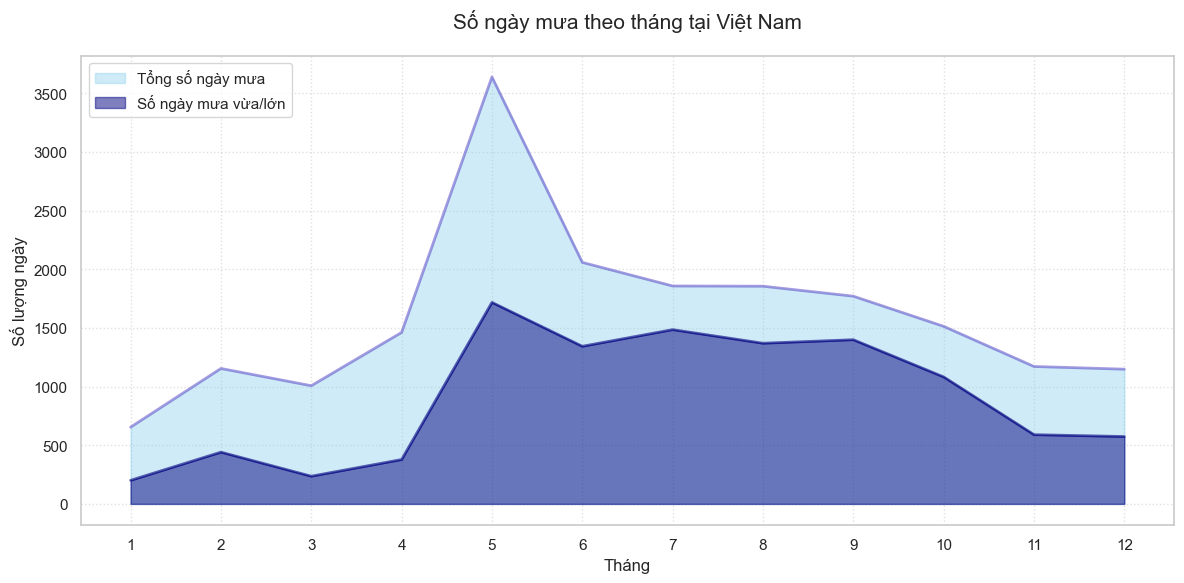

In [21]:


# 1. Chuẩn bị dữ liệu từ biến df_weather
df = df_weather.copy()
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 2. Định nghĩa danh sách mưa vừa/lớn
heavy_rain_list = [
    'Moderate or heavy rain shower', 'Moderate rain at times',
    'Heavy rain at times', 'Moderate or heavy rain with thunder',
    'Torrential rain shower', 'Moderate rain', 'Heavy rain'
]

# 3. Phân loại và gom nhóm theo tháng
# Tổng số ngày có mưa (bất kể cường độ)
total_rainy = df[df['day.daily_will_it_rain'] == 1].groupby('month').size()

# Số ngày mưa vừa và lớn
heavy_rainy = df[
    (df['day.daily_will_it_rain'] == 1) &
    (df['day.condition.text'].str.strip().isin(heavy_rain_list))
].groupby('month').size()

# Kết hợp vào một DataFrame và sắp xếp theo tháng để đường biểu đồ mượt mà
df_area = pd.DataFrame({
    'Tổng số ngày mưa': total_rainy,
    'Số ngày mưa vừa/lớn': heavy_rainy
}).fillna(0).sort_index()

# 4. Vẽ biểu đồ miền (Stacked Area Chart)
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ miền không chồng lấp (unstacked) để thấy rõ sự chênh lệch
plt.fill_between(df_area.index, df_area['Tổng số ngày mưa'], color="skyblue", alpha=0.4, label='Tổng số ngày mưa')
plt.plot(df_area.index, df_area['Tổng số ngày mưa'], color="Slateblue", alpha=0.6, linewidth=2)

plt.fill_between(df_area.index, df_area['Số ngày mưa vừa/lớn'], color="navy", alpha=0.5, label='Số ngày mưa vừa/lớn')
plt.plot(df_area.index, df_area['Số ngày mưa vừa/lớn'], color="navy", alpha=0.6, linewidth=2)

# Định dạng biểu đồ
plt.title('Số ngày mưa theo tháng tại Việt Nam', fontsize=15, pad=20)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số lượng ngày', fontsize=12)
plt.xticks(df_area.index) # Hiển thị đủ các tháng có trong dữ liệu
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

#### **Nhận xét**: 
- Mưa ở Việt Nam chủ yếu là mưa vừa và mưa to (hầu hết thời gian trong năm, số ngày mưa vừa/ mưa to chiếm từ 1/2 - 2/3 số ngày có mưa). Điều đó cho thấy tính chất khắc nghiệt của thời tiết đối với đời sống con người.

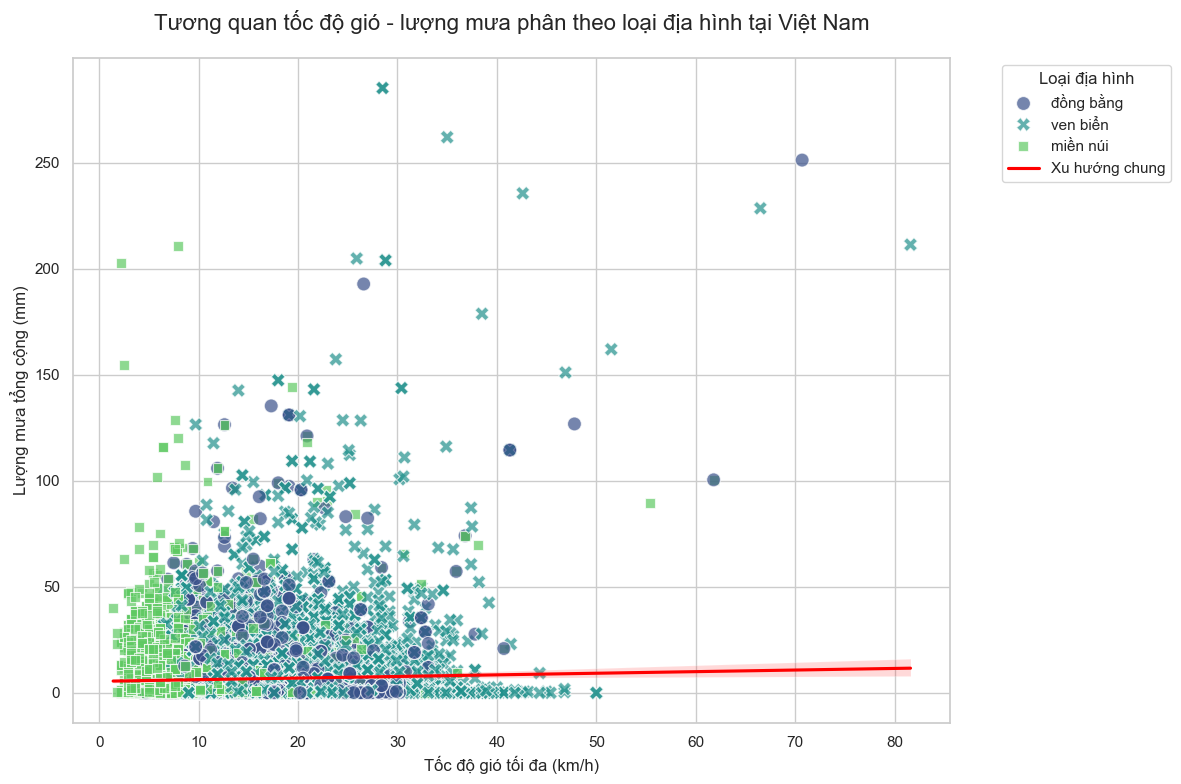

In [22]:
# 2. Thiết lập giao diện
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 3. Vẽ biểu đồ phân điểm phân loại theo địa hình (Terrain)
scatter = sns.scatterplot(
    data=df,
    x='day.maxwind_kph',
    y='day.totalprecip_mm',
    hue='location.terrain',    # Phân màu theo địa hình
    style='location.terrain',  # Phân loại ký hiệu để dễ nhìn hơn
    s=100,                     # Kích thước điểm
    alpha=0.7,
    palette='viridis'          # Bảng màu hiện đại
)

# 4. Vẽ đường xu hướng chung (regression line) cho toàn bộ dữ liệu
sns.regplot(
    data=df,
    x='day.maxwind_kph',
    y='day.totalprecip_mm',
    scatter=False,             # Không vẽ lại các điểm scatter
    color='red',
    label='Xu hướng chung'
)

# 5. Định dạng biểu đồ
plt.title('Tương quan tốc độ gió - lượng mưa phân theo loại địa hình tại Việt Nam', fontsize=16, pad=20)
plt.xlabel('Tốc độ gió tối đa (km/h)', fontsize=12)
plt.ylabel('Lượng mưa tổng cộng (mm)', fontsize=12)
plt.legend(title='Loại địa hình', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### **Nhận xét**: 
- Đồng thời, thời tiết có xu hướng diễn biến theo chiều: mưa càng to, gió càng lớn, song xu hướng này không quá mạnh. Phần lớn mưa ở khu vực đồng bằng và miền núi không kèm theo gió lớn. Song ở khu vực ven biển, hai hiện tượng này có mối tương quan rõ rệt hơn, nhấn mạnh rằng đây chính là khu vực hứng chịu thiên tai nhiều nhất cả nước.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8148\2230847801.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


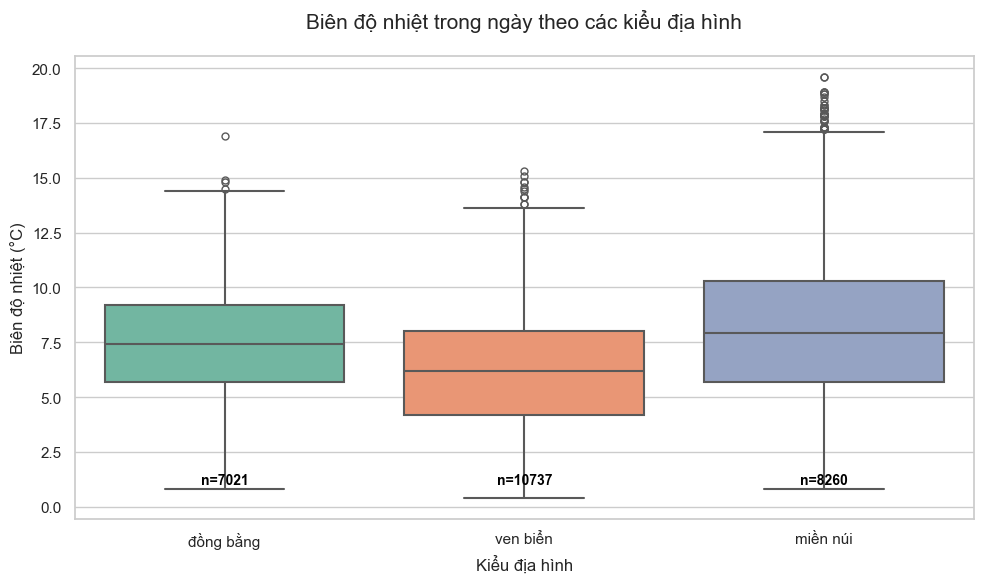

In [23]:
# 2. Tính toán biên độ nhiệt trong ngày (Temperature Range)
df['temp_range'] = df['day.maxtemp_c'] - df['day.mintemp_c']

# 3. Vẽ biểu đồ Boxplot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Vẽ Boxplot phân loại theo địa hình
ax = sns.boxplot(
    data=df,
    x='location.terrain',
    y='temp_range',
    palette='Set2',
    linewidth=1.5,
    fliersize=5 # Kích thước các điểm dị biệt (outliers)
)

# 4. Tùy chỉnh biểu đồ
plt.title('Biên độ nhiệt trong ngày theo các kiểu địa hình', fontsize=15, pad=20)
plt.xlabel('Kiểu địa hình', fontsize=12)
plt.ylabel('Biên độ nhiệt (°C)', fontsize=12)

# Thêm ghi chú số lượng mẫu để biểu đồ thêm uy tín
counts = df.groupby('location.terrain').size()
for i, label in enumerate(ax.get_xticklabels()):
    terrain_type = label.get_text()
    ax.text(i, ax.get_ylim()[1]*0.05, f'n={counts[terrain_type]}',
            ha='center', size='small', color='black', weight='semibold')

plt.tight_layout()
plt.show()

#### **Nhận xét**: 
- Tuy nhiên, ở khu vực miền núi, sự khắc nghiệt của thời tiết lại biểu hiện ở một yếu tố khác: mức chênh lệch nhiệt độ giữa ban ngày và ban đêm cực lớn, biên độ nhiệt trải rộng hơn hẳn so với 2 khu vực còn lại, đòi hỏi con người phải có khả năng thích nghi cao hơn.

# 6. Phân tích nâng cao

Phần này chúng ta sẽ đi phân tích thêm các thông số về biến động thời tiết theo vùng và những ngày có rủi ro kép

## 6.1. Biến động thời tiết theo vùng

Chỉ số trung bình chỉ cho ta biết mức điển hình, nhưng đôi khi điều quan trọng hơn là **độ dao động**.

Ví dụ:
- Hai vùng cùng nhiệt độ trung bình 26°C
- Nhưng một vùng ổn định quanh năm, vùng kia lúc rất lạnh lúc rất nóng

Ý nghĩa:
- Dao động lớn → thời tiết thay đổi mạnh hơn
- Dao động nhỏ → thời tiết ổn định hơn

#### Thuật ngữ
- **Standard deviation (độ lệch chuẩn)**: mức dao động quanh giá trị trung bình.
- **IQR**: mức trải rộng của phần dữ liệu trung tâm.

Bảng biến động thời tiết theo vùng:


,location.region,temp_std,temp_iqr,rain_std,rain_iqr,humidity_std
0,Bắc Trung Bộ và Duyên hải miền Trung,3.640761,5.2,16.054643,6.5500,8.168835
5,Đồng Bằng Sông Hồng,4.629510,7.4,14.959453,6.9000,11.727165
1,Trung du và miền núi Bắc Bộ,5.093296,7.5,13.479477,7.5300,14.144989
4,Đồng Bằng Sông Cửu Long,1.809636,2.6,9.196063,10.3000,9.305193
3,Đông Nam Bộ,1.935010,2.9,9.036347,9.3775,10.645713
2,Tây Nguyên,2.877149,3.9,8.223087,8.2000,11.817462


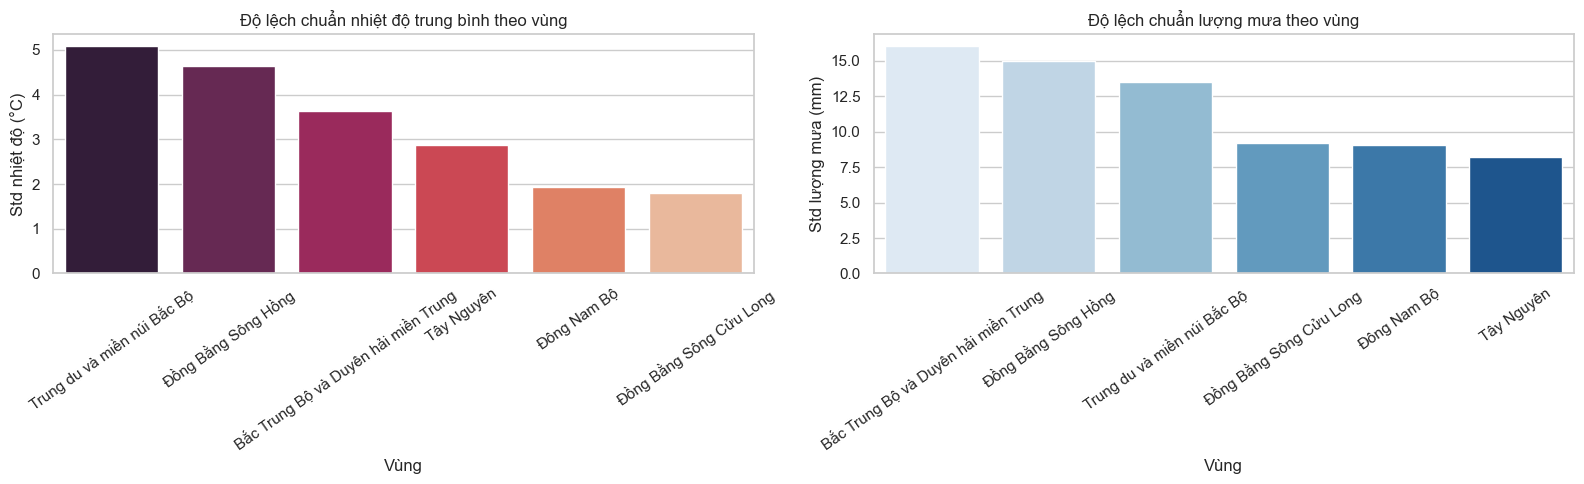

In [24]:
# Chuẩn bị dữ liệu
ext_df = df_weather.copy()
ext_df['date'] = pd.to_datetime(ext_df['date'])
ext_df['month'] = ext_df['date'].dt.month

# 1) BIẾN ĐỘNG THEO VÙNG: độ lệch chuẩn và IQR
variability = (
    ext_df.groupby('location.region')
    .agg(
        temp_std=('day.avgtemp_c', 'std'),
        rain_std=('day.totalprecip_mm', 'std'),
        humidity_std=('day.avghumidity', 'std'),
        temp_q1=('day.avgtemp_c', lambda s: s.quantile(0.25)),
        temp_q3=('day.avgtemp_c', lambda s: s.quantile(0.75)),
        rain_q1=('day.totalprecip_mm', lambda s: s.quantile(0.25)),
        rain_q3=('day.totalprecip_mm', lambda s: s.quantile(0.75))
    )
    .reset_index()
)

variability['temp_iqr'] = variability['temp_q3'] - variability['temp_q1']
variability['rain_iqr'] = variability['rain_q3'] - variability['rain_q1']

print('Bảng biến động thời tiết theo vùng:')
display(
    variability[[
        'location.region', 'temp_std', 'temp_iqr', 'rain_std', 'rain_iqr', 'humidity_std'
    ]].sort_values('rain_std', ascending=False)
)

# Trực quan hóa nhanh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=variability.sort_values('temp_std', ascending=False),
    x='location.region', y='temp_std', palette='rocket', ax=axes[0], hue='location.region', legend=False
)
axes[0].set_title('Độ lệch chuẩn nhiệt độ trung bình theo vùng')
axes[0].set_xlabel('Vùng')
axes[0].set_ylabel('Std nhiệt độ (°C)')
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(
    data=variability.sort_values('rain_std', ascending=False),
    x='location.region', y='rain_std', palette='Blues', ax=axes[1], hue='location.region', legend=False
)
axes[1].set_title('Độ lệch chuẩn lượng mưa theo vùng')
axes[1].set_xlabel('Vùng')
axes[1].set_ylabel('Std lượng mưa (mm)')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

### Nhận xét: Biến động thời tiết theo vùng

**1) Biến động nhiệt độ (temp_std, temp_iqr)**
- `Trung du và miền núi Bắc Bộ` có độ biến động nhiệt độ cao nhất (`std` khoảng 5.09, `IQR` khoảng 7.5), phản ánh tính mùa rất rõ và chênh lệch nhiệt độ lớn giữa các thời điểm trong năm.
- `Đồng Bằng Sông Hồng` đứng thứ hai (`std` khoảng 4.63, `IQR` khoảng 7.4), phù hợp với đặc trưng mùa đông lạnh hơn và mùa hè nóng ẩm.
- `Đông Nam Bộ` và `Đồng Bằng Sông Cửu Long` có biến động thấp nhất (`std` dưới 2.0), cho thấy nền nhiệt ổn định hơn quanh năm.

**2) Biến động lượng mưa (rain_std, rain_iqr)**
- `Bắc Trung Bộ và Duyên hải miền Trung` có `rain_std` cao nhất (khoảng 16.05), tức có nhiều tháng/chùm ngày mưa rất khác biệt (khô và mưa cực mạnh xen kẽ).
- `Đồng Bằng Sông Hồng` và `Trung du và miền núi Bắc Bộ` cũng có biến động mưa cao (`std` khoảng 14.96 và 13.48), cho thấy tính mùa mưa rõ.
- `Tây Nguyên` có `rain_std` thấp nhất trong 6 vùng (khoảng 8.22), tuy vẫn có mùa mưa rõ nhưng phân tán cực trị thấp hơn nhóm miền Trung.

**3) Hàm ý thực tiễn**
- Vùng có biến động cao cần chiến lược thích nghi linh hoạt hơn theo mùa (nông nghiệp, cấp thoát nước, y tế nhiệt).
- Vùng có biến động thấp phù hợp hơn cho các kế hoạch sản xuất ổn định theo chu kỳ dài.
- Nếu muốn đi sâu hơn, có thể tách thêm theo `tháng` để nhận diện chính xác các "tháng chuyển mùa rủi ro cao".

## 6.2. Ngày rủi ro kép

Phần này tạo ra 2 kiểu ngày rủi ro:
- **Nắng nóng + UV cao**
- **Mưa to + gió lớn**

Mục đích chính là gợi ý:
- Nơi nào cần chú ý sức khỏe nhiệt nhiều hơn
- Nơi nào cần chú ý rủi ro thiên tai nhiều hơn

#### Thuật ngữ:
- **Threshold / ngưỡng**: mức cắt để xác định “cao”.
- **Percentile / phân vị**: ví dụ 90% nghĩa là thuộc nhóm cao nhất của dữ liệu.

Tỷ lệ (%) ngày rủi ro kép theo vùng:


,location.region,risk_hot_uv,risk_rain_wind
0,Bắc Trung Bộ và Duyên hải miền Trung,10.117606,2.109997
5,Đồng Bằng Sông Hồng,6.869221,1.519155
4,Đồng Bằng Sông Cửu Long,13.186813,1.434159
3,Đông Nam Bộ,18.724778,1.331719
1,Trung du và miền núi Bắc Bộ,3.943272,0.501557
2,Tây Nguyên,7.554479,0.387409



Top 10 tỉnh - rủi ro nắng nóng + UV cao (% ngày):


location.name
Bình Dương         25.181598
Đồng Nai           25.181598
TP. Hồ Chí Minh    25.181598
Tây Ninh           23.728814
Quảng Ngãi         23.244552
Vĩnh Long          17.917676
An Giang           17.433414
Long An            17.191283
Bến Tre            17.191283
Tiền Giang         17.191283
Name: risk_hot_uv, dtype: float64

Top 10 tỉnh - rủi ro mưa to + gió lớn (% ngày):


location.name
Kiên Giang         7.021792
Quảng Bình         5.326877
Ninh Thuận         3.874092
Bà Rịa-Vũng Tàu    3.631961
Phú Yên            3.389831
Bình Định          3.389831
Hà Tĩnh            2.905569
Nghệ An            2.663438
Cà Mau             2.179177
Tây Ninh           2.179177
Name: risk_rain_wind, dtype: float64

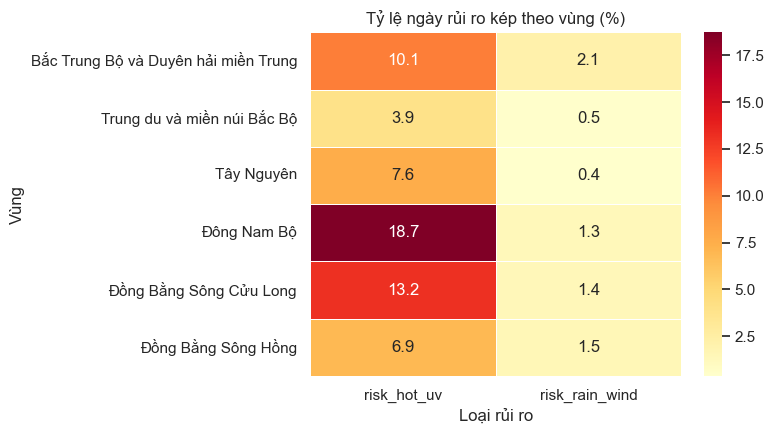

In [26]:
# 2) RỦI RO KÉP: nắng nóng + UV cao, mưa to + gió lớn
risk_df = ext_df.copy()

# Ngưỡng theo phân vị để phù hợp với chính bộ dữ liệu
hot_threshold = risk_df['day.maxtemp_c'].quantile(0.90)
rain_threshold = risk_df['day.totalprecip_mm'].quantile(0.90)
wind_threshold = risk_df['day.maxwind_kph'].quantile(0.90)

risk_df['risk_hot_uv'] = (risk_df['day.maxtemp_c'] >= hot_threshold) & (risk_df['day.uv'] >= 8)
risk_df['risk_rain_wind'] = (risk_df['day.totalprecip_mm'] >= rain_threshold) & (risk_df['day.maxwind_kph'] >= wind_threshold)

risk_summary_region = (
    risk_df.groupby('location.region')[['risk_hot_uv', 'risk_rain_wind']]
    .mean()
    .mul(100)
    .reset_index()
)

print('Tỷ lệ (%) ngày rủi ro kép theo vùng:')
display(risk_summary_region.sort_values('risk_rain_wind', ascending=False))

# Top tỉnh có rủi ro kép cao nhất
top_hot_uv = (
    risk_df.groupby('location.name')['risk_hot_uv'].mean().mul(100)
    .sort_values(ascending=False).head(10)
)
top_rain_wind = (
    risk_df.groupby('location.name')['risk_rain_wind'].mean().mul(100)
    .sort_values(ascending=False).head(10)
)

print('\nTop 10 tỉnh - rủi ro nắng nóng + UV cao (% ngày):')
display(top_hot_uv)
print('Top 10 tỉnh - rủi ro mưa to + gió lớn (% ngày):')
display(top_rain_wind)

# Heatmap theo vùng
heatmap_data = risk_summary_region.set_index('location.region')[['risk_hot_uv', 'risk_rain_wind']]

plt.figure(figsize=(8, 4.5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Tỷ lệ ngày rủi ro kép theo vùng (%)')
plt.xlabel('Loại rủi ro')
plt.ylabel('Vùng')
plt.tight_layout()
plt.show()

### Nhận xét: Ngày rủi ro kép

**1) Rủi ro nắng nóng + UV cao nổi bật hơn rủi ro mưa to + gió lớn**
- Tỷ lệ `risk_hot_uv` cao nhất ở `Đông Nam Bộ` (khoảng 18.7%), tiếp theo là `Đồng Bằng Sông Cửu Long` (khoảng 13.2%) và `Bắc Trung Bộ và Duyên hải miền Trung` (khoảng 10.1%).
- Tỷ lệ `risk_rain_wind` nhìn chung thấp hơn nhiều ở mọi vùng (cao nhất khoảng 2.1% tại `Bắc Trung Bộ và Duyên hải miền Trung`).

**2) Nhóm tỉnh cần ưu tiên theo dõi**
- Nhóm nóng + UV cao nổi bật: `Bình Dương`, `Đồng Nai`, `TP. Hồ Chí Minh`, `Tây Ninh`, `Quảng Ngãi`.
- Nhóm mưa to + gió lớn nổi bật: `Kiên Giang`, `Quảng Bình`, `Ninh Thuận`, `Bà Rịa-Vũng Tàu`, `Phú Yên`, `Bình Định`.

**3) Ý nghĩa phân bố không gian**
- Cụm `Đông Nam Bộ` và một phần `Đồng Bằng Sông Cửu Long` chịu áp lực nắng nóng/UV lớn hơn, phù hợp với nền nhiệt cao ổn định bạn đã quan sát trước đó.
- Rủi ro mưa-gió tập trung ở dải ven biển, phản ánh tác động của hoàn lưu biển, gió mùa và các đợt nhiễu động mạnh.

# 7. Kết luận

Từ các phân tích ở trên, có thể rút ra 3 ý chính:

- Thời tiết Việt Nam nhìn chung mang tính nhiệt đới rõ rệt: nóng, ẩm và mưa nhiều.
- Sự khác nhau giữa các vùng không quá lớn ở mức trung bình, nhưng khi xét theo **tháng**, **địa hình** và **mức độ cực đoan** thì có phân hóa khá rõ.
- Một số rủi ro nổi bật là nắng gắt/UV cao và các đợt mưa lớn theo mùa, cho thấy nhu cầu thích nghi theo từng vùng và từng thời điểm trong năm.

Tóm lại, dữ liệu cho thấy bức tranh thời tiết Việt Nam vừa có tính thống nhất toàn quốc, vừa có khác biệt quan trọng theo không gian và thời gian. Đây là nền tảng tốt để mở rộng sang các phân tích dự báo và ứng dụng thực tế.

# 8. Phần mở rộng

Ở phần này, nhóm chúng mình có thực hiện train một model để dự báo một ngày có mưa hay không, nếu các bạn có hứng thú có thể đọc thêm ở notebook này

Link: [Predict a rainy day](https://github.com/ThanhKieuVT/AIO-2026-Warm-02/blob/main/Bog%202/blog2-vietnam-weather-data-analysis-and-rain.ipynb)

